In [11]:
import ast
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
import pandas as pd
import seaborn as sns

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [12]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')]
df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])
df_DA_US_exploded = df_DA_US.explode('job_skills')

In [13]:
df_DA_Optimal_Skill = df_DA_US_exploded.groupby('job_skills').agg(skill_count=('job_skills', 'count'), Median_Salary=('salary_year_avg', 'median')).sort_values(by='skill_count', ascending=False)

df_DA_Count = len(df_DA_US)
df_DA_Count
df_DA_Optimal_Skill['percent'] = (df_DA_Optimal_Skill['skill_count']/df_DA_Count) * 100
df_DA_Optimal_Skill = df_DA_Optimal_Skill[df_DA_Optimal_Skill['percent'] >= 5]
df_DA_Optimal_Skill

,skill_count,Median_Salary,percent
job_skills,,,
sql,2508,91000.00,57.655172
excel,1808,84392.00,41.563218
python,1431,97500.00,32.896552
tableau,1364,92875.00,31.356322
sas,926,90000.00,21.287356
r,893,92500.00,20.528736
power bi,838,90000.00,19.264368
powerpoint,462,85000.00,10.620690
word,461,81194.75,10.597701


In [14]:
from adjustText import adjust_text

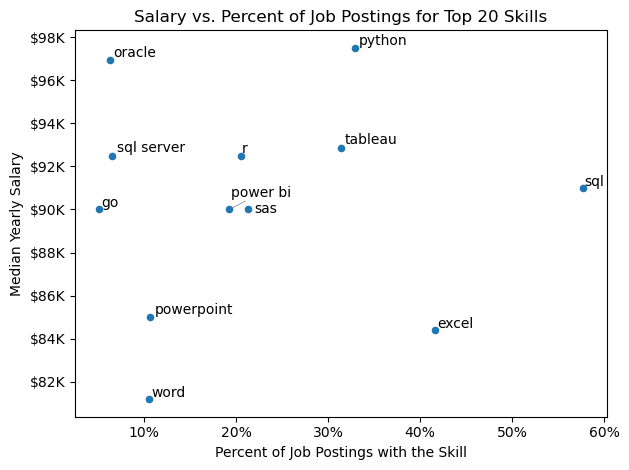

In [15]:
from adjustText import adjust_text
from matplotlib.ticker import PercentFormatter
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

df_DA_Optimal_Skill.plot(
    kind='scatter',
    x='percent',
    y='Median_Salary',
    ax=ax
)

texts = []

for i, txt in enumerate(df_DA_Optimal_Skill.index):
    texts.append(
        ax.text(
            df_DA_Optimal_Skill['percent'].iloc[i],
            df_DA_Optimal_Skill['Median_Salary'].iloc[i],
            txt
        )
    )

adjust_text(
    texts,
    arrowprops=dict(
        arrowstyle='->',
        color='gray',
        lw=0.5
    )
)

# Format x-axis as percentage
ax.xaxis.set_major_formatter(PercentFormatter())

# Format y-axis as salary in thousands
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K')
)

plt.xlabel('Percent of Job Postings with the Skill')
plt.ylabel('Median Yearly Salary')
plt.title('Salary vs. Percent of Job Postings for Top 20 Skills')

plt.tight_layout()
plt.show()

In [16]:
df['job_type_skills'].head(10)

0                                                  NaN
1    {'analyst_tools': ['power bi', 'tableau'], 'pr...
2    {'analyst_tools': ['dax'], 'cloud': ['azure'],...
3    {'cloud': ['aws'], 'libraries': ['tensorflow',...
4    {'cloud': ['oracle', 'aws'], 'other': ['ansibl...
5    {'cloud': ['gcp'], 'programming': ['python', '...
6    {'cloud': ['gcp', 'bigquery'], 'databases': ['...
7    {'cloud': ['gcp', 'azure', 'aws', 'bigquery', ...
8    {'analyst_tools': ['excel', 'powerpoint', 'pow...
9    {'analyst_tools': ['excel'], 'cloud': ['azure'...
Name: job_type_skills, dtype: str

In [17]:
df_technology = df['job_type_skills'].copy()
df_technology = df_technology.drop_duplicates()
df_technology = df_technology.dropna()
df_technology



technology_dict = {}

for row in df_technology:
    row_dict = ast.literal_eval(row)
    for key, value in row_dict.items():
        if key in technology_dict:
            technology_dict[key] += value
        else: 
            technology_dict[key] = value



for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))


technology_dict

{'analyst_tools': ['tableau',
  'powerbi',
  'nuix',
  'looker',
  'spss',
  'msaccess',
  'spreadsheet',
  'microstrategy',
  'excel',
  'power bi',
  'visio',
  'ms access',
  'esquisse',
  'powerpoint',
  'datarobot',
  'sheets',
  'cognos',
  'qlik',
  'alteryx',
  'dax',
  'sas',
  'splunk',
  'sharepoint',
  'ssrs',
  'outlook',
  'sap',
  'ssis',
  'word'],
 'programming': ['javascript',
  'c#',
  'dart',
  'erlang',
  'html',
  'swift',
  'ocaml',
  'apl',
  'clojure',
  'c++',
  'mongodb',
  'python',
  'visual basic',
  'no-sql',
  'assembly',
  'elixir',
  'matlab',
  'lua',
  'rust',
  'solidity',
  'vb.net',
  'nosql',
  'vba',
  'php',
  'go',
  'f#',
  'java',
  'groovy',
  'objective-c',
  'julia',
  'pascal',
  'bash',
  'lisp',
  'delphi',
  'fortran',
  'c',
  'visualbasic',
  'shell',
  'haskell',
  'ruby',
  'css',
  'sass',
  'r',
  'sas',
  'cobol',
  'kotlin',
  'golang',
  'scala',
  'powershell',
  'crystal',
  't-sql',
  'typescript',
  'perl',
  'mongo',
  '

In [19]:
df_technology = pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])
df_technology = df_technology.explode('skills')
df_technology


,technology,skills
0,analyst_tools,tableau
0,analyst_tools,powerbi
0,analyst_tools,nuix
0,analyst_tools,looker
0,analyst_tools,spss
...,...,...
9,sync,symphony
9,sync,webex
9,sync,google chat
9,sync,twilio


In [40]:
df_merge = df_DA_Optimal_Skill.merge(df_technology, left_on= 'job_skills', right_on='skills').set_index('skills')
df_merge

,skill_count,Median_Salary,percent,technology
skills,,,,
sql,2508,91000.00,57.655172,programming
excel,1808,84392.00,41.563218,analyst_tools
python,1431,97500.00,32.896552,programming
tableau,1364,92875.00,31.356322,analyst_tools
sas,926,90000.00,21.287356,analyst_tools
sas,926,90000.00,21.287356,programming
r,893,92500.00,20.528736,programming
power bi,838,90000.00,19.264368,analyst_tools
powerpoint,462,85000.00,10.620690,analyst_tools


4 [0.41966248 0.70971566]
5 [-0.59368245 -0.79587789]


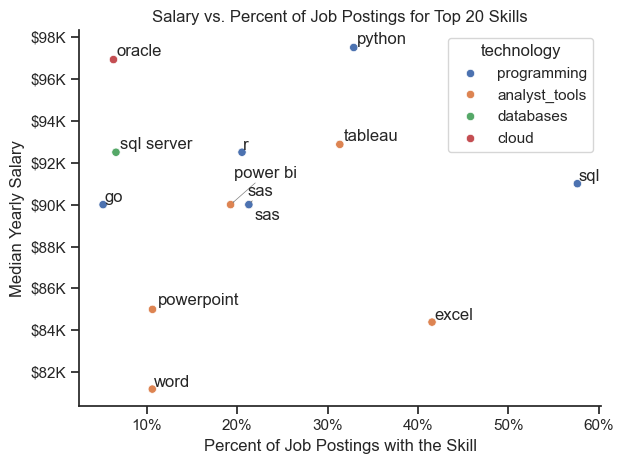

In [45]:
from adjustText import adjust_text
from matplotlib.ticker import PercentFormatter
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

#df_merge.plot(kind='scatter',x='percent',y='Median_Salary',ax=ax)

sns.scatterplot(data=df_merge, x='percent', y='Median_Salary', ax=ax, hue='technology')
sns.despine()
sns.set_theme(style='ticks')

texts = []

for i, txt in enumerate(df_merge.index):
    texts.append(
        ax.text(
            df_merge['percent'].iloc[i],
            df_merge['Median_Salary'].iloc[i],
            txt
        )
    )

adjust_text(
    texts,
    arrowprops=dict(
        arrowstyle='->',
        color='gray',
        lw=0.5
    )
)

# Format x-axis as percentage
ax.xaxis.set_major_formatter(PercentFormatter())

# Format y-axis as salary in thousands
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K')
)

plt.xlabel('Percent of Job Postings with the Skill')
plt.ylabel('Median Yearly Salary')
plt.title('Salary vs. Percent of Job Postings for Top 20 Skills')

plt.tight_layout()
plt.show()